In [1]:
import snowflake.connector
import pandas as pd
import getpass
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' %x)
pd.set_option('display.max_columns', None)

In [2]:
conn = snowflake.connector.connect(
     user=input("Snowflake username: "),
    password=getpass.getpass("Snowflake password: "),
    account=input("Account identifier: "),
    warehouse = 'CMS_WH',
    database = 'CMS_PROJECT',
    schema = 'REVENUE_CYCLE'
)
print("Python connection successful")


Snowflake username:  shantanunayar
Snowflake password:  ········
Account identifier:  QHJNHYN-WZ62559


Python connection successful


In [3]:
query = """
SELECT * FROM MEDICARE_PROVIDER_SERVICE
LIMIT 1000
"""
df = pd.read_sql(query,conn)
print(df.shape)
df.head()

/var/folders/10/cg68x6sj1rx_46lzjx372ycc0000gn/T/ipykernel_11714/728437845.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


(1000, 28)


,RNDRNG_NPI,RNDRNG_PRVDR_LAST_ORG_NAME,RNDRNG_PRVDR_FIRST_NAME,RNDRNG_PRVDR_MI,RNDRNG_PRVDR_CRDNTLS,RNDRNG_PRVDR_ENT_CD,RNDRNG_PRVDR_ST1,RNDRNG_PRVDR_ST2,RNDRNG_PRVDR_CITY,RNDRNG_PRVDR_STATE_ABRVTN,RNDRNG_PRVDR_STATE_FIPS,RNDRNG_PRVDR_ZIP5,RNDRNG_PRVDR_RUCA,RNDRNG_PRVDR_RUCA_DESC,RNDRNG_PRVDR_CNTRY,RNDRNG_PRVDR_TYPE,RNDRNG_PRVDR_MDCR_PRTCPTG_IND,HCPCS_CD,HCPCS_DESC,HCPCS_DRUG_IND,PLACE_OF_SRVC,TOT_BENES,TOT_SRVCS,TOT_BENE_DAY_SRVCS,AVG_SBMTD_CHRG,AVG_MDCR_ALOWD_AMT,AVG_MDCR_PYMT_AMT,AVG_MDCR_STDZD_AMT
0,1013066810,Huff,Donald,W,M.D.,I,142 W 5th St,NaN,Cookeville,TN,47,38501,4,Micropolitan area core: primary flow within an...,US,Diagnostic Radiology,Y,93970,Ultrasound study of arm or leg veins with comp...,N,F,62,64,64,102.38,30.05,22.74,23.24
1,1013066869,Haq,Seema,NaN,M.D.,I,3300 Colorado Blvd,NaN,Denton,TX,48,76210,2,Metropolitan area high commuting: primary flow...,US,Endocrinology,Y,10006,Fine needle aspiration biopsy using ultrasound...,N,O,12,13,12,700.00,57.34,45.69,46.86
2,1013066869,Haq,Seema,NaN,M.D.,I,3300 Colorado Blvd,NaN,Denton,TX,48,76210,2,Metropolitan area high commuting: primary flow...,US,Endocrinology,Y,99215,Established patient office or other outpatient...,N,O,70,177,177,256.00,167.96,125.56,133.76
3,1013067040,Fox,Rena,K,MD,I,400 Parnassus Ave,NaN,San Francisco,CA,06,94143,1,Metropolitan area core: primary flow within an...,US,Internal Medicine,Y,99215,Established patient office or other outpatient...,N,O,139,272,272,773.00,161.86,111.65,96.31
4,1013067057,Riella,Leonardo,V,"M.D., PHD",I,55 Fruit Street,White 5,Boston,MA,25,02114,1,Metropolitan area core: primary flow within an...,US,Nephrology,Y,99233,Subsequent hospital care with moderate levelof...,N,F,36,89,89,498.73,124.04,98.67,91.71


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   RNDRNG_NPI                     1000 non-null   str    
 1   RNDRNG_PRVDR_LAST_ORG_NAME     1000 non-null   str    
 2   RNDRNG_PRVDR_FIRST_NAME        973 non-null    str    
 3   RNDRNG_PRVDR_MI                739 non-null    str    
 4   RNDRNG_PRVDR_CRDNTLS           940 non-null    str    
 5   RNDRNG_PRVDR_ENT_CD            1000 non-null   str    
 6   RNDRNG_PRVDR_ST1               1000 non-null   str    
 7   RNDRNG_PRVDR_ST2               287 non-null    str    
 8   RNDRNG_PRVDR_CITY              1000 non-null   str    
 9   RNDRNG_PRVDR_STATE_ABRVTN      1000 non-null   str    
 10  RNDRNG_PRVDR_STATE_FIPS        1000 non-null   str    
 11  RNDRNG_PRVDR_ZIP5              1000 non-null   str    
 12  RNDRNG_PRVDR_RUCA              1000 non-null   str    
 13  

In [5]:
query = """
SELECT * FROM MEDICARE_PROVIDER_SERVICE
SAMPLE(50000 ROWS)
"""

df = pd.read_sql(query,conn)
print(f"Rows loaded: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

/var/folders/10/cg68x6sj1rx_46lzjx372ycc0000gn/T/ipykernel_11714/968792310.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


Rows loaded: 50,000
Columns: 28


,RNDRNG_NPI,RNDRNG_PRVDR_LAST_ORG_NAME,RNDRNG_PRVDR_FIRST_NAME,RNDRNG_PRVDR_MI,RNDRNG_PRVDR_CRDNTLS,RNDRNG_PRVDR_ENT_CD,RNDRNG_PRVDR_ST1,RNDRNG_PRVDR_ST2,RNDRNG_PRVDR_CITY,RNDRNG_PRVDR_STATE_ABRVTN,RNDRNG_PRVDR_STATE_FIPS,RNDRNG_PRVDR_ZIP5,RNDRNG_PRVDR_RUCA,RNDRNG_PRVDR_RUCA_DESC,RNDRNG_PRVDR_CNTRY,RNDRNG_PRVDR_TYPE,RNDRNG_PRVDR_MDCR_PRTCPTG_IND,HCPCS_CD,HCPCS_DESC,HCPCS_DRUG_IND,PLACE_OF_SRVC,TOT_BENES,TOT_SRVCS,TOT_BENE_DAY_SRVCS,AVG_SBMTD_CHRG,AVG_MDCR_ALOWD_AMT,AVG_MDCR_PYMT_AMT,AVG_MDCR_STDZD_AMT
0,1871668368,Li,George,G,M.D.,I,4161 Tamiami Trl,Suite 201,Port Charlotte,FL,12,33952,1,Metropolitan area core: primary flow within an...,US,Neurology,Y,99203,New patient office or other outpatient visit w...,N,O,71,71,71,212.00,112.62,74.13,70.98
1,1740682210,Mississippi Cvs Pharmacy Llc,NaN,NaN,NaN,O,1435 N. Frontage Rd,NaN,Vicksburg,MS,28,39180,4,Micropolitan area core: primary flow within an...,US,Mass Immunizer Roster Biller,Y,90480,Admn sarscov2 vacc 1 dose,N,O,168,175,175,37.85,36.97,36.97,42.56
2,1578515128,Wetherly,Mark,L,MD,I,790 Church St Ne,Ste 400,Marietta,GA,13,30060,1,Metropolitan area core: primary flow within an...,US,Diagnostic Radiology,Y,76705,Limited ultrasound scan of abdomen,N,F,31,31,31,142.00,26.64,18.17,17.64
3,1659351484,Cherny,Richard,C,M.D.,I,5008 Brittonfield Pkwy,Suite 700,East Syracuse,NY,36,13057,1,Metropolitan area core: primary flow within an...,US,Hematology-Oncology,Y,83615,Lactate dehydrogenase (enzyme) level,N,O,15,15,15,18.00,5.92,5.92,5.92
4,1871583096,Lee,Richard,J,MD PHD,I,55 Fruit St,Yaw 7e,Boston,MA,25,02114,1,Metropolitan area core: primary flow within an...,US,Hematology-Oncology,Y,99213,Established patient office or other outpatient...,N,F,136,200,200,280.15,69.18,50.39,46.70


In [6]:
df.describe()

,TOT_BENES,TOT_SRVCS,TOT_BENE_DAY_SRVCS,AVG_SBMTD_CHRG,AVG_MDCR_ALOWD_AMT,AVG_MDCR_PYMT_AMT,AVG_MDCR_STDZD_AMT
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,75.03,255.08,121.79,426.56,106.48,83.11,82.76
std,256.72,3537.18,458.41,1627.71,355.46,283.53,291.20
min,11.00,11.00,11.00,0.01,0.01,0.00,0.00
25%,17.00,21.00,20.00,72.81,25.67,19.85,19.60
50%,32.00,44.00,41.00,179.79,71.39,52.29,52.48
75%,71.00,117.00,105.00,367.00,120.87,90.55,90.61
max,25447.00,568000.00,52445.00,97873.86,25158.93,20037.32,19897.33


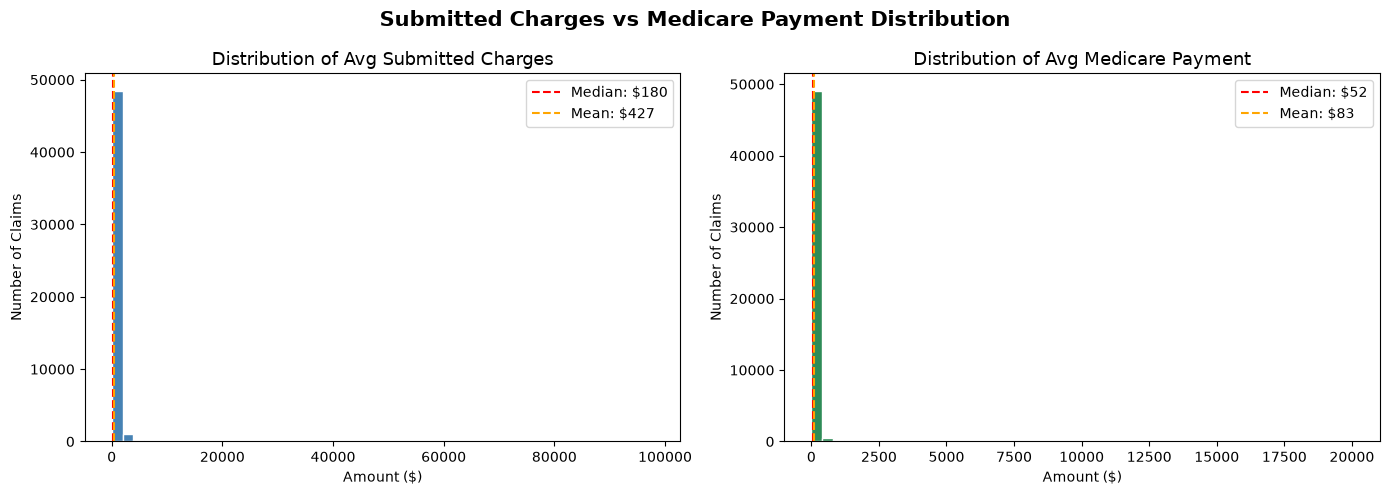

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart - Submitted Charges
axes[0].hist(df['AVG_SBMTD_CHRG'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Avg Submitted Charges', fontsize=13)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Number of Claims')
axes[0].axvline(df['AVG_SBMTD_CHRG'].median(), color='red', linestyle='--', label=f"Median: ${df['AVG_SBMTD_CHRG'].median():,.0f}")
axes[0].axvline(df['AVG_SBMTD_CHRG'].mean(), color='orange', linestyle='--', label=f"Mean: ${df['AVG_SBMTD_CHRG'].mean():,.0f}")
axes[0].legend()

# Right chart - Medicare Payment
axes[1].hist(df['AVG_MDCR_PYMT_AMT'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution of Avg Medicare Payment', fontsize=13)
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Number of Claims')
axes[1].axvline(df['AVG_MDCR_PYMT_AMT'].median(), color='red', linestyle='--', label=f"Median: ${df['AVG_MDCR_PYMT_AMT'].median():,.0f}")
axes[1].axvline(df['AVG_MDCR_PYMT_AMT'].mean(), color='orange', linestyle='--', label=f"Mean: ${df['AVG_MDCR_PYMT_AMT'].mean():,.0f}")
axes[1].legend()

plt.suptitle('Submitted Charges vs Medicare Payment Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

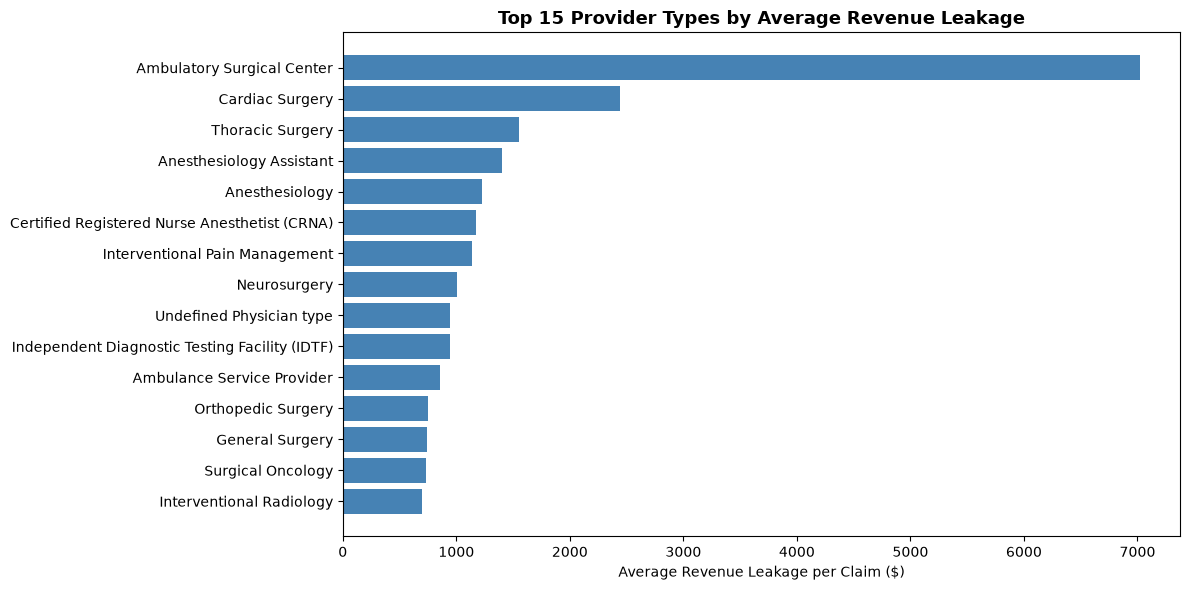

In [8]:
# Calculate leakage per row
df['LEAKAGE'] = df['AVG_SBMTD_CHRG'] - df['AVG_MDCR_PYMT_AMT']

# Get top 15 provider types by average leakage
leakage_by_type = (df.groupby('RNDRNG_PRVDR_TYPE')['LEAKAGE']
                     .mean()
                     .sort_values(ascending=False)
                     .head(15)
                     .reset_index())

plt.figure(figsize=(12, 6))
bars = plt.barh(leakage_by_type['RNDRNG_PRVDR_TYPE'], 
                leakage_by_type['LEAKAGE'], 
                color='steelblue')
plt.xlabel('Average Revenue Leakage per Claim ($)')
plt.title('Top 15 Provider Types by Average Revenue Leakage', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

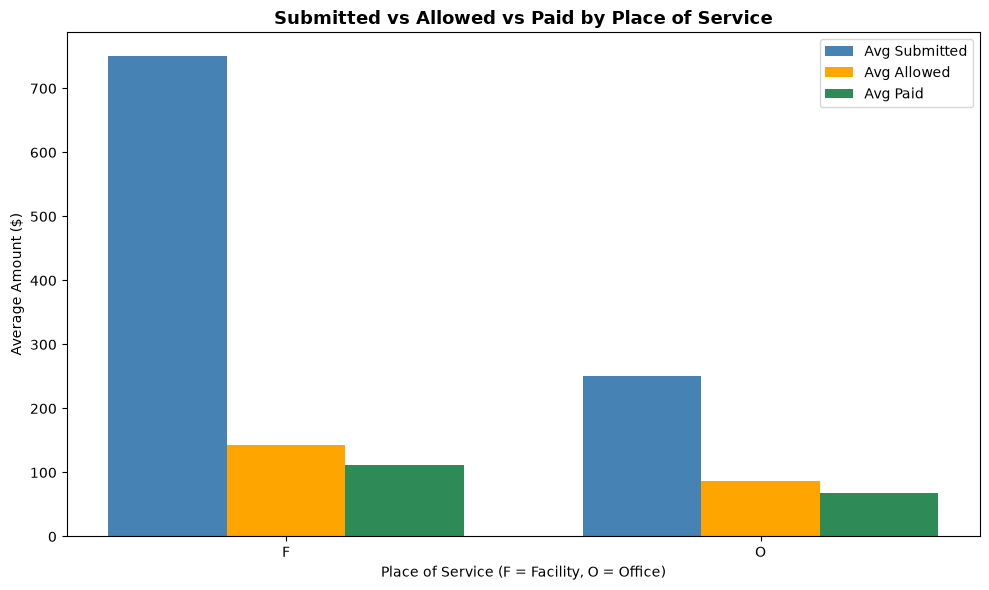

In [9]:
place_summary = df.groupby('PLACE_OF_SRVC').agg(
    Avg_Submitted=('AVG_SBMTD_CHRG', 'mean'),
    Avg_Allowed=('AVG_MDCR_ALOWD_AMT', 'mean'),
    Avg_Paid=('AVG_MDCR_PYMT_AMT', 'mean'),
    Claim_Count=('RNDRNG_NPI', 'count')
).reset_index()

x = range(len(place_summary))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar([i - width for i in x], place_summary['Avg_Submitted'], width, label='Avg Submitted', color='steelblue')
plt.bar([i for i in x], place_summary['Avg_Allowed'], width, label='Avg Allowed', color='orange')
plt.bar([i + width for i in x], place_summary['Avg_Paid'], width, label='Avg Paid', color='seagreen')

plt.xticks(x, place_summary['PLACE_OF_SRVC'])
plt.xlabel('Place of Service (F = Facility, O = Office)')
plt.ylabel('Average Amount ($)')
plt.title('Submitted vs Allowed vs Paid by Place of Service', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

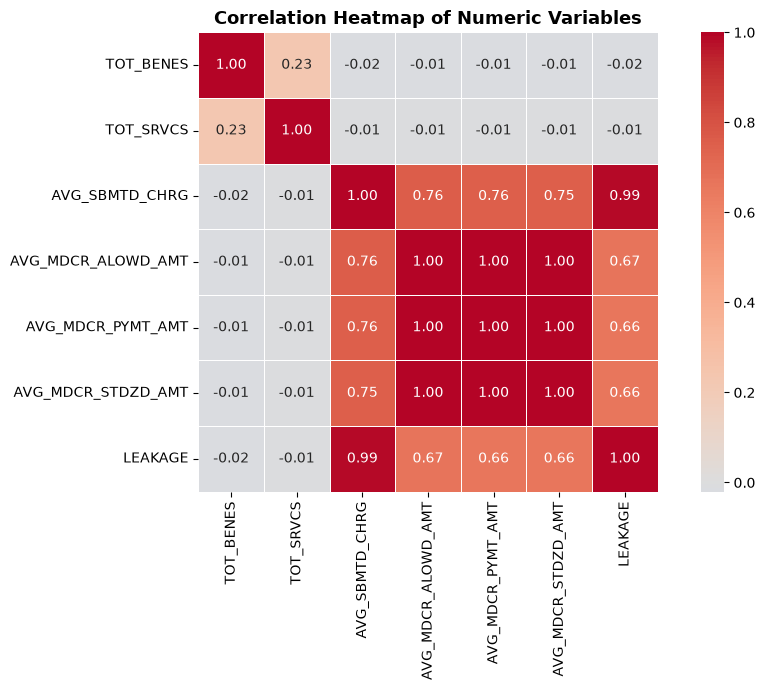

In [10]:
numeric_cols = ['TOT_BENES', 'TOT_SRVCS', 'AVG_SBMTD_CHRG', 
                'AVG_MDCR_ALOWD_AMT', 'AVG_MDCR_PYMT_AMT', 
                'AVG_MDCR_STDZD_AMT', 'LEAKAGE']

plt.figure(figsize=(10, 7))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation numbers inside cells
            fmt='.2f',            # Round to 2 decimal places
            cmap='coolwarm',      # Red = high correlation, Blue = low
            center=0,             # Center the color scale at 0
            square=True,          # Make cells square
            linewidths=0.5)

plt.title('Correlation Heatmap of Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()